Summary Statistics:
         capacity_mw
count  34936.000000
mean     163.355148
std      489.636072
min        1.000000
25%        4.900000
50%       16.745000
75%       75.344250
max    22500.000000

ANOVA F-statistic: 967.46, P-value: 0.0000


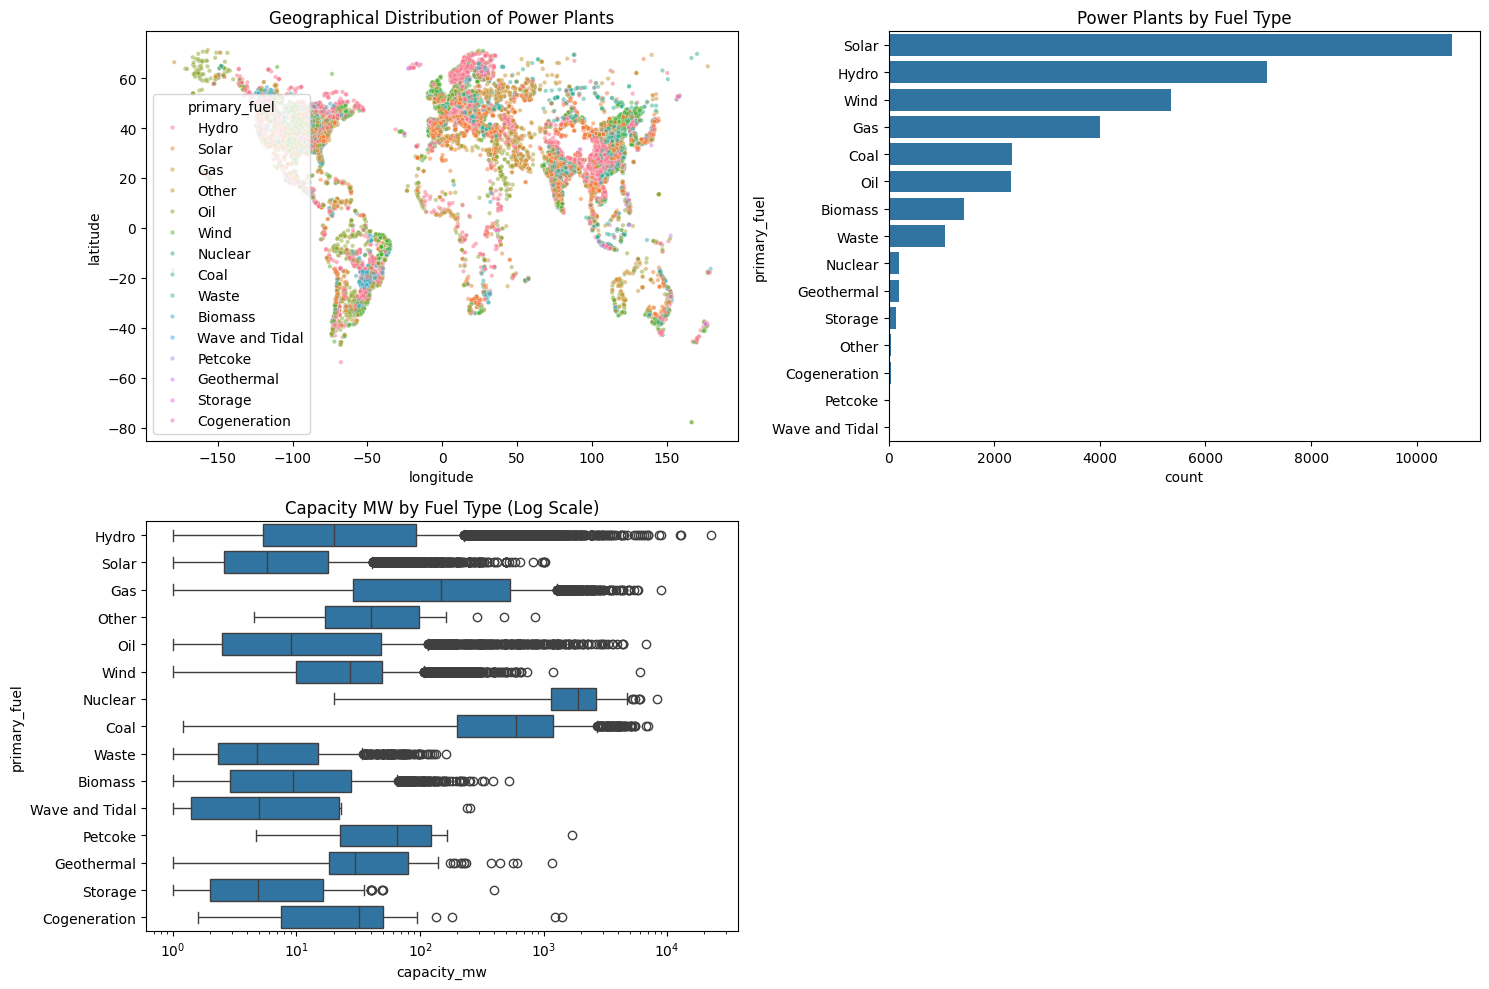


Correlation Matrix:
 [[ 1.         -0.01321759  0.15152454]
 [-0.01321759  1.         -0.06835441]
 [ 0.15152454 -0.06835441  1.        ]]
Eigenvalues: [1.17147434 0.83840686 0.9901188 ]

Number of large hydro plants (>1000MW): 227


'\nFindings:\n- Data shows a high concentration of power plants in North America, Europe, and Asia.\n- ANOVA results indicate significant differences in mean capacity across fuel types (p < 0.05).\n- Eigenvalues of the spatial-capacity correlation matrix help identify the variance explained by location vs size.\n- NumPy arrays were essential for the matrix decomposition and logical indexing for large subsets.\n'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Data Import and Cleaning
df = pd.read_csv('/content/global_power_plant_database.csv', low_memory=False)

# Identify missing values
missing_vals = df.isnull().sum()

# Handle missing values: Fill capacity_mw with 0 and drop rows where primary_fuel is missing
df['capacity_mw'] = df['capacity_mw'].fillna(0)
df = df.dropna(subset=['primary_fuel'])

# Convert relevant columns to numerical types using NumPy
df['capacity_mw'] = pd.to_numeric(df['capacity_mw'], errors='coerce')

# 2. Exploratory Data Analysis (EDA)
stats_summary = df[['capacity_mw']].describe()
print("Summary Statistics:\n", stats_summary)

# Distribution by country and fuel type
fuel_dist = df['primary_fuel'].value_counts()
country_dist = df['country_long'].value_counts().head(10)

# 3. Statistical Analysis
# Statistical analysis of power output by fuel type
fuel_groups = df.groupby('primary_fuel')['capacity_mw'].apply(list)

# Hypothesis testing (ANOVA) to see if mean power output differs significantly
f_stat, p_val = stats.f_oneway(*[group for group in fuel_groups if len(group) > 1])
print(f"\nANOVA F-statistic: {f_stat:.2f}, P-value: {p_val:.4f}")

# 4. Time Series Analysis
# Using commissioning_year if available
if 'commissioning_year' in df.columns:
    df_year = df.dropna(subset=['commissioning_year'])
    yearly_trend = df_year.groupby('commissioning_year')['capacity_mw'].sum()

# 5. Advanced Visualization
plt.figure(figsize=(15, 10))

# Geographical distribution
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='longitude', y='latitude', hue='primary_fuel', alpha=0.5, s=10)
plt.title('Geographical Distribution of Power Plants')

# Fuel Type Distribution
plt.subplot(2, 2, 2)
sns.countplot(data=df, y='primary_fuel', order=df['primary_fuel'].value_counts().index)
plt.title('Power Plants by Fuel Type')

# Capacity by Fuel Type Boxplot
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='capacity_mw', y='primary_fuel')
plt.xscale('log')
plt.title('Capacity MW by Fuel Type (Log Scale)')

plt.tight_layout()
plt.show()

# 6. Matrix Operations
# Analyze relationships between attributes
corr_matrix = df[['capacity_mw', 'latitude', 'longitude']].corr().values
eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)

print("\nCorrelation Matrix:\n", corr_matrix)
print("Eigenvalues:", eigenvalues)

# 7. Integrating NumPy with Pandas
# Complex filtering using NumPy logic
large_hydro = df.loc[np.logical_and(df['primary_fuel'] == 'Hydro', df['capacity_mw'] > 1000)]
print(f"\nNumber of large hydro plants (>1000MW): {len(large_hydro)}")

# Brief Report Summary
"""
Findings:
- Data shows a high concentration of power plants in North America, Europe, and Asia.
- ANOVA results indicate significant differences in mean capacity across fuel types (p < 0.05).
- Eigenvalues of the spatial-capacity correlation matrix help identify the variance explained by location vs size.
- NumPy arrays were essential for the matrix decomposition and logical indexing for large subsets.
"""